In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import os
import re
import itertools
import pickle
import json
import datetime

from tqdm.notebook import tqdm
from collections import defaultdict

# Load interaction data

In [2]:
# actions = pd.read_csv("../source_data/actions_updated.csv")[["user_id", "jd_no", "browsed", "delivered", "satisfied"]]
# actions["label"] = actions[["browsed", "delivered", "satisfied"]].sum(axis=1)
# actions.head()

In [3]:
## We only consider candidates with at least 5 matching vacancies in the dataset
## This not only saves time, but also improves results later on
# candidate_counts = actions[actions["label"] > 0].groupby("user_id")["jd_no"].count()
# candidate_list = candidate_counts[candidate_counts >= 5].index

## Load KG

In [4]:
G = nx.DiGraph()

with open("../outputs/inferred_outputs/kg_qwen_structured.edgelist", encoding="utf-8") as f:
    for line in tqdm(f.readlines()):
        
        if "err:error" in line:
            print(line)
            continue
            
        s, p, o = eval(line)
        G.add_edge(s, o, edge_type=p)

  0%|          | 0/2786074 [00:00<?, ?it/s]

In [5]:
# Find neighbors of each node (for quicker retrieval later on) 
all_neighbors = {}

H = G.to_undirected()

for n in tqdm(G.nodes):
    all_neighbors[n] = set(H.neighbors(n))
    
all_neighbors = {k: {i for i in v if not pd.isna(i)} for k, v in all_neighbors.items()}

  0%|          | 0/383577 [00:00<?, ?it/s]

## Load interactions

In [8]:
df_int = pd.read_csv("../../dataset/final_dataset/contacted_anon.csv").fillna(0)

# Only keep vacancies with at least 15 interactions
relevant_vacancies = df_int["cvid"].value_counts()[df_int["cvid"].value_counts() >= 15].index

# Filter to only relevant vacancies
df_int = df_int[df_int["cvid"].isin(relevant_vacancies.values)][["humanjobid", "response", "cvid"]]

df_int.head()

,humanjobid,response,cvid
28,1527549.0,0,1ea333bcf408489d88d6bb4ecad3852d
36,1527549.0,no4,0
53,1527507.0,0,6f38a6778f1249b5b14658aed49f5348
61,1527507.0,0,238e44044b5348e09dba220756613ac6
62,1527507.0,0,6e5a9a5cac7e454bb17c85853850b108


In [9]:
df_int["response"].value_counts()

response
0      22223
no4     2392
ok4     2055
ok6      299
no5       30
ok5       16
Name: count, dtype: int64

# K random walks

In [10]:
def k_walk(G, a, b, all_neighbors, k=6, walks=100):
    print(a, b)
    sub_graph = []

    if (not (a in G)) or (not (b in G)):
        return None
            
    # Number of walks
    for _ in range(walks):
        path = ()
        
        visited = set()
        
        prev_node = a
        old = None
        
        # Length of each walk
        for _ in range(k):
            # Choose a random neighbor of our current node
            candidates = all_neighbors[prev_node] # if prev_node in all_neighbors else set(G.neighbors(prev_node))
                
            # Don't backtrack unless absolutely necessary
            if old and len(candidates) > 1:
                candidates = candidates - set([old])
            
            # If we can reach the target from the current node, 
            # do so, as long as that wouldn't create a duplicate path
            if b in candidates and (prev_node, b) not in set(sub_graph):
                next_node = b
            else:
                if candidates:
                    next_node = np.random.choice(list(candidates))
                    
                    if next_node in visited:
                        continue
                    else:
                        visited.add(next_node)                    
                else:
                    break
            
            path += (prev_node, next_node),

            # Update
            old = prev_node
            prev_node = next_node
            
            # If we found the target, store
            if next_node == b:
                sub_graph.extend(path)
                break
                
    sg = set(sub_graph)
    sg -= {(a, b)}
    sg -= {(b, a)}
                
    H = G.edge_subgraph(sg)
               
    return H

In [19]:
cons = []

for row in df_int.itertuples():
    ex = k_walk(H, 
                f"jie:position_{int(row[1])}",
                f"jie:_jie_candidate_{row[3]}_", 
                all_neighbors, k=25, walks=500)

    if ex:
        cons.append(len(ex.nodes) > 0)
        break
    else:
        cons.append(False)

    print(np.mean(cons))

jie:position_1527549 jie:_jie_candidate_1ea333bcf408489d88d6bb4ecad3852d_


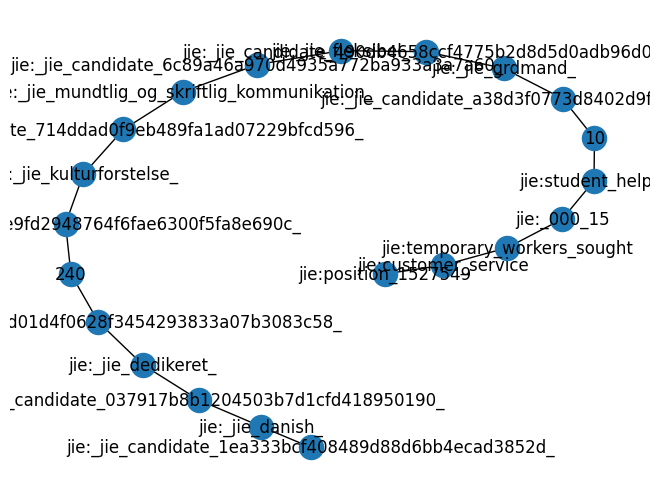

In [20]:
nx.draw_spring(ex, with_labels=True)